# HW1, задача 2: три пружины, $\mu = 110^\circ$

Одна точка массы $m$ в $(x,y)$ и **три** пружины к неподвижным якорям. Угол $\mu = 110^\circ$.

Дальше: символьный потенциал и силы в `sympy`, равновесие численно, линеаризация $m\ddot\eta + K\eta=0$ с аналитикой по модам, затем явный / неявный / полуявный Эйлер и Верле на полной нелинейной модели, графики энергии и траектории.


In [1]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy.optimize import root

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

sp.init_printing(use_latex="mathjax")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["grid.linestyle"] = "--"

MU_DEG = 110.0
MU = math.radians(MU_DEG)
print(f"mu = {MU_DEG} deg = {MU:.6f} rad")


mu = 110.0 deg = 1.919862 rad


## Геометрия

$$
x_1=0,\ y_1=L_{\mathrm{wall}},\qquad
x_2=L_{\mathrm{floor}},\ y_2=0,\qquad
x_3=L_{\mathrm{tilt}}\sin\mu,\ y_3=L_{\mathrm{tilt}}\cos\mu.
$$

$$
L_i=\sqrt{(x-x_i)^2+(y-y_i)^2},\qquad
V=\sum_{i=1}^3 \frac{k_i}{2}(L_i-L_{i0})^2 + mgy.
$$


In [2]:
x, y = sp.symbols("x y", real=True)
m, g = sp.symbols("m g", positive=True, real=True)
k1, k2, k3 = sp.symbols("k_1 k_2 k_3", positive=True, real=True)
L10, L20, L30 = sp.symbols("L_10 L_20 L_30", positive=True, real=True)

Lwall, Lfloor, Ltilt = sp.symbols("L_wall L_floor L_tilt", positive=True, real=True)
mu_s = sp.symbols("mu", positive=True, real=True)

x1n, y1n = 0, Lwall
x2n, y2n = Lfloor, 0
x3n, y3n = Ltilt * sp.sin(mu_s), Ltilt * sp.cos(mu_s)

L1 = sp.sqrt((x - x1n) ** 2 + (y - y1n) ** 2)
L2 = sp.sqrt((x - x2n) ** 2 + (y - y2n) ** 2)
L3 = sp.sqrt((x - x3n) ** 2 + (y - y3n) ** 2)

V = (
    sp.Rational(1, 2) * k1 * (L1 - L10) ** 2
    + sp.Rational(1, 2) * k2 * (L2 - L20) ** 2
    + sp.Rational(1, 2) * k3 * (L3 - L30) ** 2
    + m * g * y
)
F = -sp.Matrix([sp.diff(V, x), sp.diff(V, y)])
K = sp.hessian(V, (x, y))

print("V(x,y):")
display(sp.Eq(sp.Symbol("V"), V))
print("\nF = -grad V:")
display(sp.Eq(sp.MatrixSymbol("F", 2, 1), F))
print("\nK = Hess(V):")
display(sp.Eq(sp.MatrixSymbol("K", 2, 2), K))


V(x,y):


                                                2                              ↪
               ⎛          _____________________⎞       ⎛          ____________ ↪
               ⎜         ╱  2                2 ⎟       ⎜         ╱  2          ↪
            k₁⋅⎝-L₁₀ + ╲╱  x  + (-L_wall + y)  ⎠    k₂⋅⎝-L₂₀ + ╲╱  y  + (-L_fl ↪
V = g⋅m⋅y + ───────────────────────────────────── + ────────────────────────── ↪
                              2                                       2        ↪

↪            2                                                               2
↪ __________⎞       ⎛          _____________________________________________⎞ 
↪         2 ⎟       ⎜         ╱                    2                      2 ⎟ 
↪ oor + x)  ⎠    k₃⋅⎝-L₃₀ + ╲╱  (-Lₜᵢₗₜ⋅sin(μ) + x)  + (-Lₜᵢₗₜ⋅cos(μ) + y)  ⎠ 
↪ ──────────── + ─────────────────────────────────────────────────────────────
↪                                              2                              


F = -grad V:


    ⎡         ⎛          _____________________⎞      ⎛          ______________ ↪
    ⎢         ⎜         ╱  2                2 ⎟      ⎜         ╱  2            ↪
    ⎢    k₁⋅x⋅⎝-L₁₀ + ╲╱  x  + (-L_wall + y)  ⎠   k₂⋅⎝-L₂₀ + ╲╱  y  + (-L_floo ↪
    ⎢  - ────────────────────────────────────── - ──────────────────────────── ↪
    ⎢              _____________________                          ____________ ↪
    ⎢             ╱  2                2                          ╱  2          ↪
    ⎢           ╲╱  x  + (-L_wall + y)                         ╲╱  y  + (-L_fl ↪
F = ⎢                                                                          ↪
    ⎢          ⎛          _____________________⎞                      ⎛        ↪
    ⎢          ⎜         ╱  2                2 ⎟                      ⎜        ↪
    ⎢       k₁⋅⎝-L₁₀ + ╲╱  x  + (-L_wall + y)  ⎠⋅(-L_wall + y)   k₂⋅y⋅⎝-L₂₀ +  ↪
    ⎢-g⋅m - ────────────────────────────────────────────────── - ───────────── ↪
    ⎢                       


K = Hess(V):


    ⎡        ⎛          _____________________⎞                            ⎛    ↪
    ⎢      2 ⎜         ╱  2                2 ⎟              2             ⎜    ↪
    ⎢  k₁⋅x ⋅⎝-L₁₀ + ╲╱  x  + (-L_wall + y)  ⎠          k₁⋅x           k₁⋅⎝-L₁ ↪
    ⎢- ─────────────────────────────────────── + ─────────────────── + ─────── ↪
    ⎢                              3/2            2                2           ↪
    ⎢         ⎛ 2                2⎞              x  + (-L_wall + y)            ↪
    ⎢         ⎝x  + (-L_wall + y) ⎠                                          ╲ ↪
K = ⎢                                                                          ↪
    ⎢                                                                          ↪
    ⎢                                                                          ↪
    ⎢                                                                        k ↪
    ⎢                                                                        ─ ↪
    ⎢                       

## Равновесие

Ищем $q_0$: $\mathbf F(q_0)=\mathbf 0$ методом `scipy.optimize.root` (символьные $\mathbf F$, $K$ через `sympy`).


In [3]:
params = {
    m: 1.0,
    g: 9.81,
    k1: 40.0,
    k2: 40.0,
    k3: 40.0,
    L10: 0.52,
    L20: 0.52,
    L30: 0.52,
    mu_s: MU,
    Lwall: 1.15,
    Lfloor: 1.25,
    Ltilt: 1.15,
}

V_sub = V.subs(params)
F_sub = F.subs(params)
K_sub = K.subs(params)

F_num = sp.lambdify((x, y), F_sub, modules="numpy")
U_num = sp.lambdify((x, y), V_sub, modules="numpy")
K_num_fun = sp.lambdify((x, y), K_sub, modules="numpy")

Lw = float(params[Lwall])
Lf = float(params[Lfloor])
Lt = float(params[Ltilt])
C1 = np.array([0.0, Lw], dtype=float)
C2 = np.array([Lf, 0.0], dtype=float)
C3 = np.array([Lt * math.sin(MU), Lt * math.cos(MU)], dtype=float)


def force_np(pos):
    return np.asarray(F_num(float(pos[0]), float(pos[1])), dtype=float).reshape(2)


guesses = [
    np.array([0.35, 0.35]),
    np.array([0.55, 0.30]),
    np.array([0.45, 0.50]),
    (C1 + C2 + C3) / 3.0,
]

solution = None
for guess in guesses:
    candidate = root(force_np, guess)
    if candidate.success and np.linalg.norm(force_np(candidate.x)) < 1e-7:
        solution = candidate
        break

if solution is None:
    raise RuntimeError("Равновесие не найдено — измените параметры или guesses.")

q_eq = solution.x.astype(float)
K_eq = np.array(K_num_fun(q_eq[0], q_eq[1]), dtype=float)
MASS = float(params[m])

print("C1, C2, C3:\n", C1, C2, C3, sep="\n")
print("q0 =", q_eq, "|F| =", np.linalg.norm(force_np(q_eq)))
print("K(q0) =\n", K_eq)
print("eig(K/m) =", np.linalg.eigvalsh(K_eq / MASS))


C1, C2, C3:

[0.   1.15]
[1.25 0.  ]
[ 1.08064651 -0.39332316]
q0 = [0.59757877 0.21408671] |F| = 5.6207423206974594e-09
K(q0) =
 [[ 87.3310893  -30.52682372]
 [-30.52682372  76.84388318]]
eig(K/m) = [ 51.11358853 113.06138395]


## Аналитика линеаризованной системы

$m\ddot\eta + K(q_0)\eta=0$, решение через собственные моды; графики энергии и траектории в стиле TwoSprings (чёрная энергия, `royalblue` траектория, красная точка равновесия).


omega = [ 7.14937679 10.63303268]


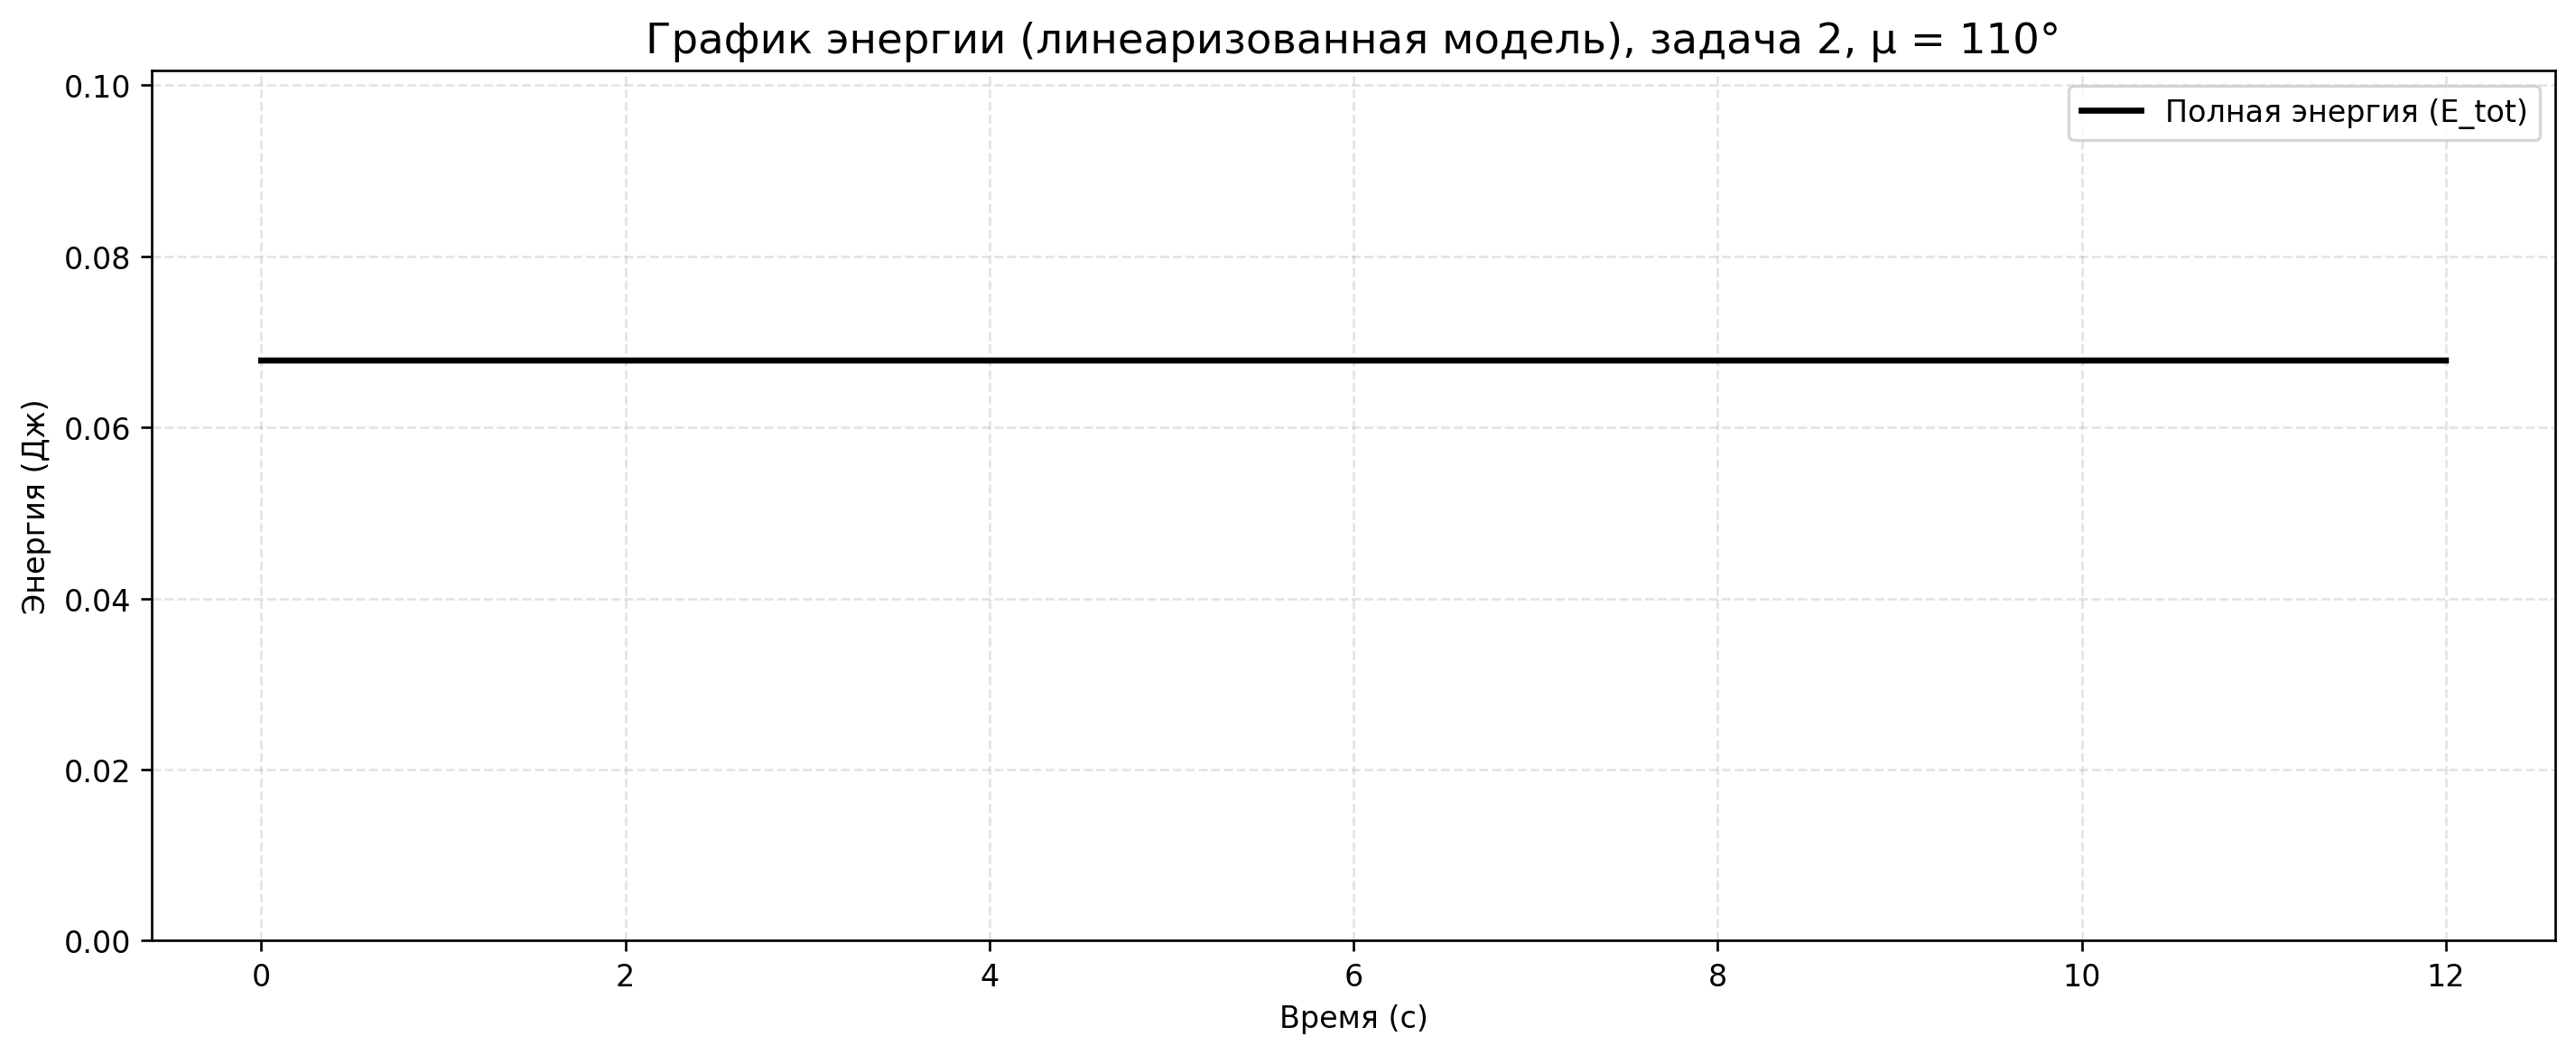

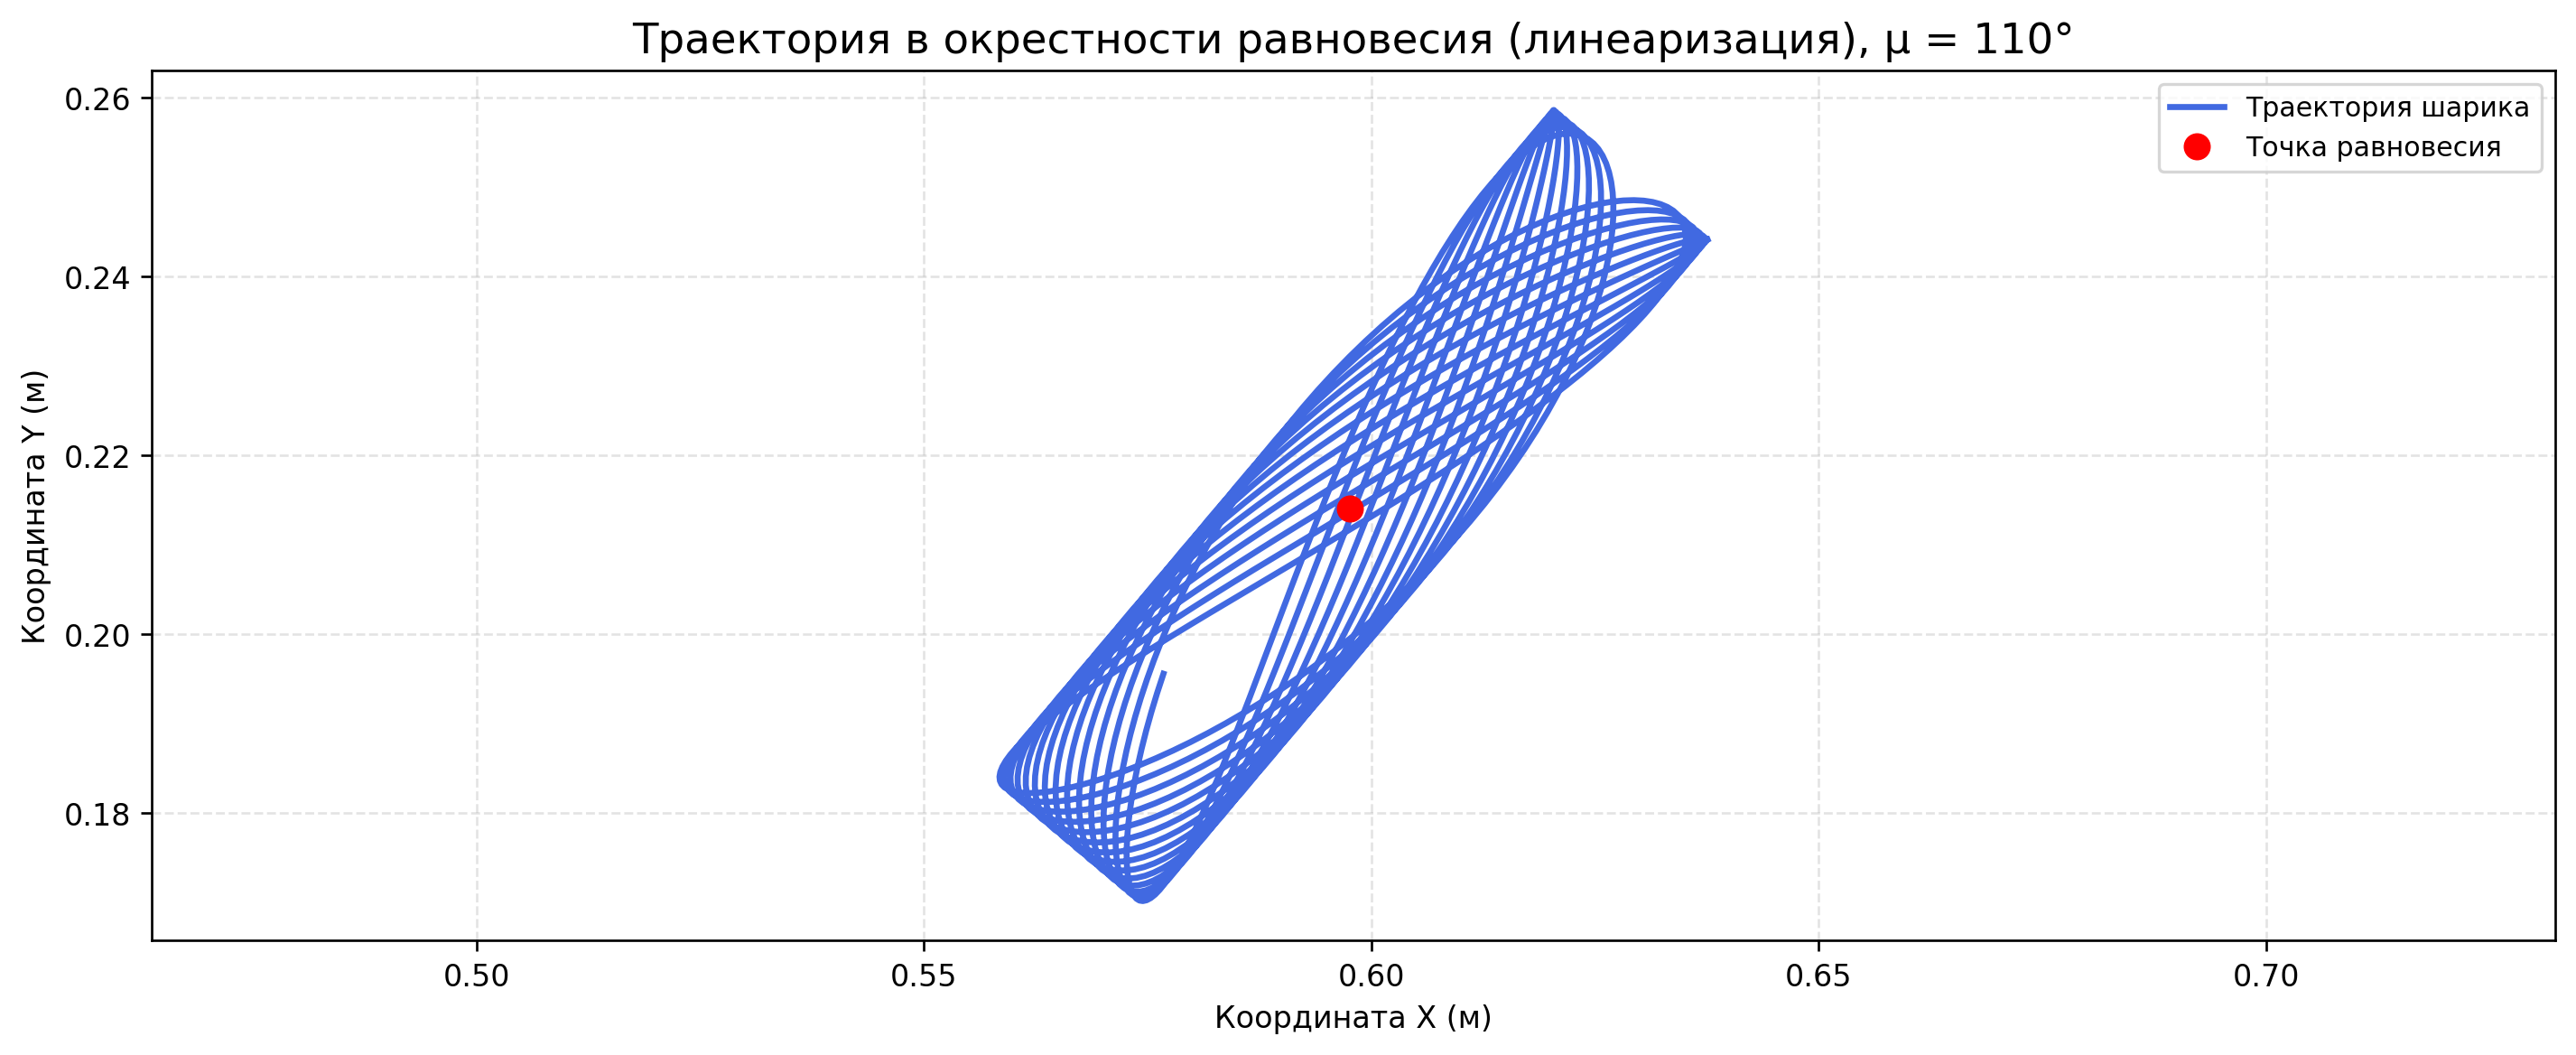

In [4]:
def linear_analytic_solution(ts, q0, v0, q_eq, K_eq, mass):
    eigvals, P = np.linalg.eigh(K_eq / mass)
    if np.any(eigvals <= 0):
        raise RuntimeError("K/m должна быть SPD в равновесии.")
    omega = np.sqrt(eigvals)
    eta0 = q0 - q_eq
    c = P.T @ eta0
    d = P.T @ v0
    modes = np.cos(np.outer(ts, omega)) * c + np.sin(np.outer(ts, omega)) * (d / omega)
    eta = modes @ P.T
    mode_vel = -np.sin(np.outer(ts, omega)) * (omega * c) + np.cos(np.outer(ts, omega)) * d
    vel = mode_vel @ P.T
    pos = q_eq + eta
    return pos, vel, omega


q0_linear = q_eq + np.array([0.04, 0.03])
v0_linear = np.zeros(2)
ts = np.linspace(0.0, 12.0, 1600)
pos_lin, vel_lin, omega = linear_analytic_solution(ts, q0_linear, v0_linear, q_eq, K_eq, MASS)
eta = pos_lin - q_eq
E_lin = 0.5 * MASS * np.sum(vel_lin**2, axis=1) + 0.5 * np.einsum("ni,ij,nj->n", eta, K_eq, eta)

print("omega =", omega)

plt.figure(figsize=(12, 5))
plt.plot(ts, E_lin, color="black", lw=2, label="Полная энергия (E_tot)")
plt.title("График энергии (линеаризованная модель), задача 2, μ = 110°", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, float(np.max(E_lin)) * 1.5 + 1e-15)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(pos_lin[:, 0], pos_lin[:, 1], color="royalblue", lw=2, label="Траектория шарика")
plt.plot(q_eq[0], q_eq[1], "ro", markersize=8, label="Точка равновесия")
#plt.scatter([C1[0], C2[0], C3[0]], [C1[1], C2[1], C3[1]], c=["purple", "green", "orange"], s=45, zorder=5, label="Якоря")
plt.title("Траектория в окрестности равновесия (линеаризация), μ = 110°", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.axis("equal")
plt.grid(True, linestyle="--")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## Численная нелинейная модель

$\dot q = v,\ \dot v = \mathbf F(q)/m$. Те же четыре интегратора, что в задаче 1.


In [5]:
def acceleration(q):
    return force_np(q) / MASS


def total_energy(q, v):
    return 0.5 * MASS * float(np.dot(v, v)) + float(U_num(float(q[0]), float(q[1])))


def step_explicit_euler(q, v, h):
    a = acceleration(q)
    return q + h * v, v + h * a


def step_semi_implicit_euler(q, v, h):
    v_next = v + h * acceleration(q)
    return q + h * v_next, v_next


def step_implicit_euler(q, v, h):
    def residual(z):
        q_next = z[:2]
        v_next = z[2:]
        return np.concatenate([q_next - q - h * v_next, v_next - v - h * acceleration(q_next)])

    q_guess, v_guess = step_semi_implicit_euler(q, v, h)
    sol = root(residual, np.concatenate([q_guess, v_guess]), method="hybr")
    if not sol.success:
        raise RuntimeError("Неявный Эйлер: root не сошёлся")
    return sol.x[:2], sol.x[2:]


def step_velocity_verlet(q, v, h):
    a0 = acceleration(q)
    q_next = q + h * v + 0.5 * h * h * a0
    a1 = acceleration(q_next)
    v_next = v + 0.5 * h * (a0 + a1)
    return q_next, v_next


METHODS = {
    "explicit": ("Явный Эйлер", step_explicit_euler),
    "implicit": ("Неявный Эйлер", step_implicit_euler),
    "semi": ("Полуявный Эйлер", step_semi_implicit_euler),
    "verlet": ("Верле", step_velocity_verlet),
}


def simulate_methods(q0, v0, h, T):
    steps = int(T / h) + 1
    time = np.linspace(0.0, h * (steps - 1), steps)
    results = {}
    for method_id, (label, stepper) in METHODS.items():
        q_hist = np.zeros((steps, 2))
        v_hist = np.zeros((steps, 2))
        e_hist = np.zeros(steps)
        q_hist[0] = q0
        v_hist[0] = v0
        e_hist[0] = total_energy(q0, v0)
        q_curr, v_curr = q0.copy(), v0.copy()
        for i in range(1, steps):
            q_curr, v_curr = stepper(q_curr, v_curr, h)
            q_hist[i] = q_curr
            v_hist[i] = v_curr
            e_hist[i] = total_energy(q_curr, v_curr)
        results[method_id] = {"label": label, "q": q_hist, "v": v_hist, "E": e_hist}
    return time, results


time_small, results_small = simulate_methods(q0_linear.copy(), v0_linear.copy(), h=0.005, T=12.0)
q0_methods = q_eq + np.array([0.16, 0.12])
v0_methods = np.array([0.12, -0.08])
time, results = simulate_methods(q0_methods, v0_methods, h=0.012, T=18.0)

print("Симуляции завершены")
for mid, r in results.items():
    drift = r["E"][-1] - r["E"][0]
    print(f"{r['label']:<22} dE = {drift:+.5e} J")


Симуляции завершены
Явный Эйлер            dE = +3.55882e+09 J
Неявный Эйлер          dE = -1.02631e+00 J
Полуявный Эйлер        dE = -3.67265e-02 J
Верле                  dE = -6.56706e-04 J


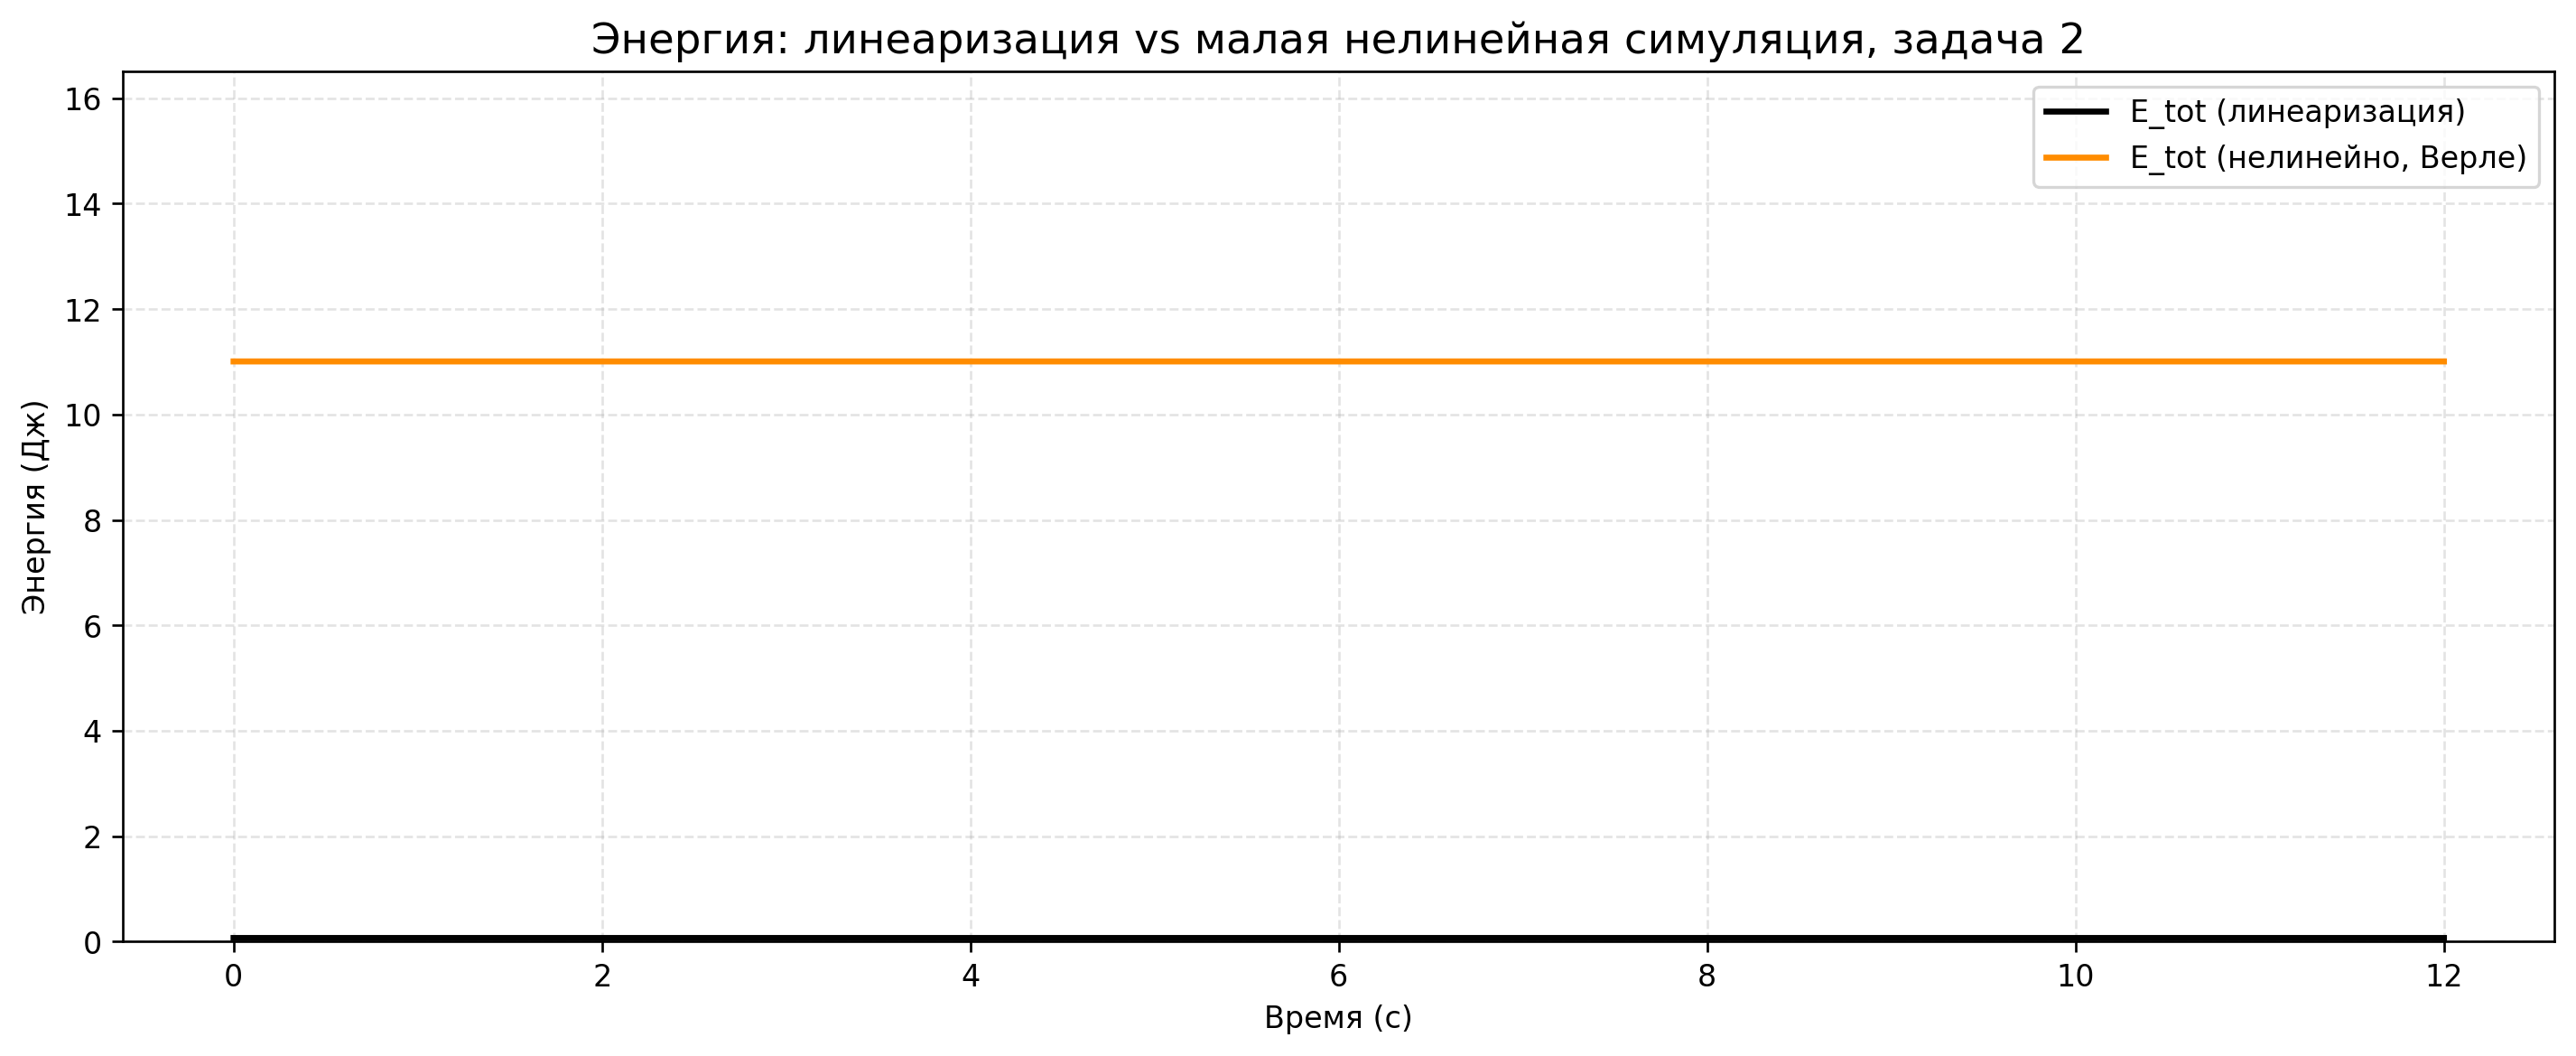

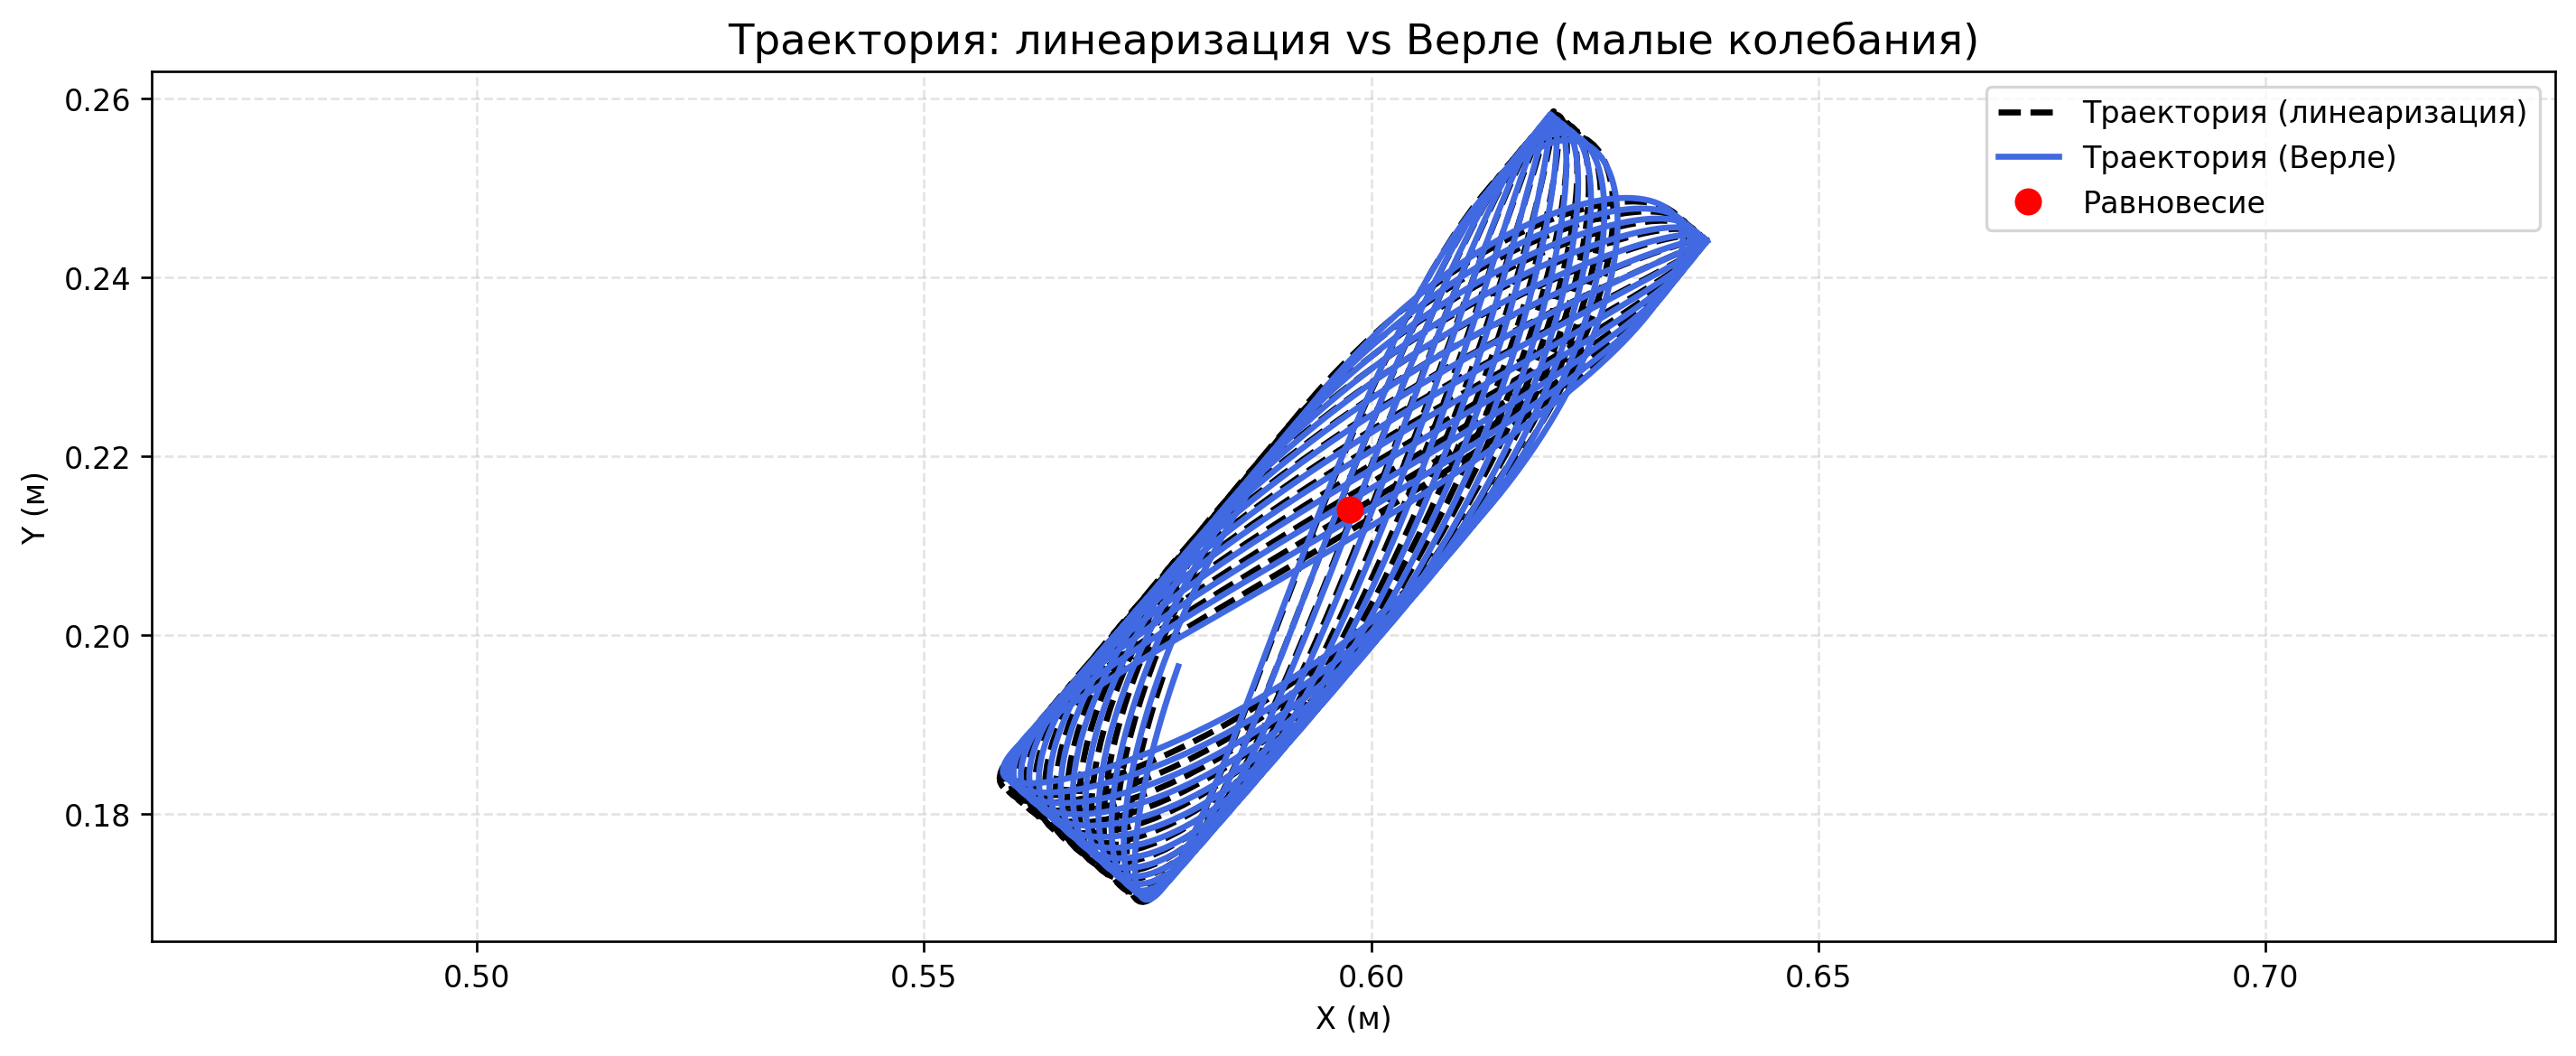

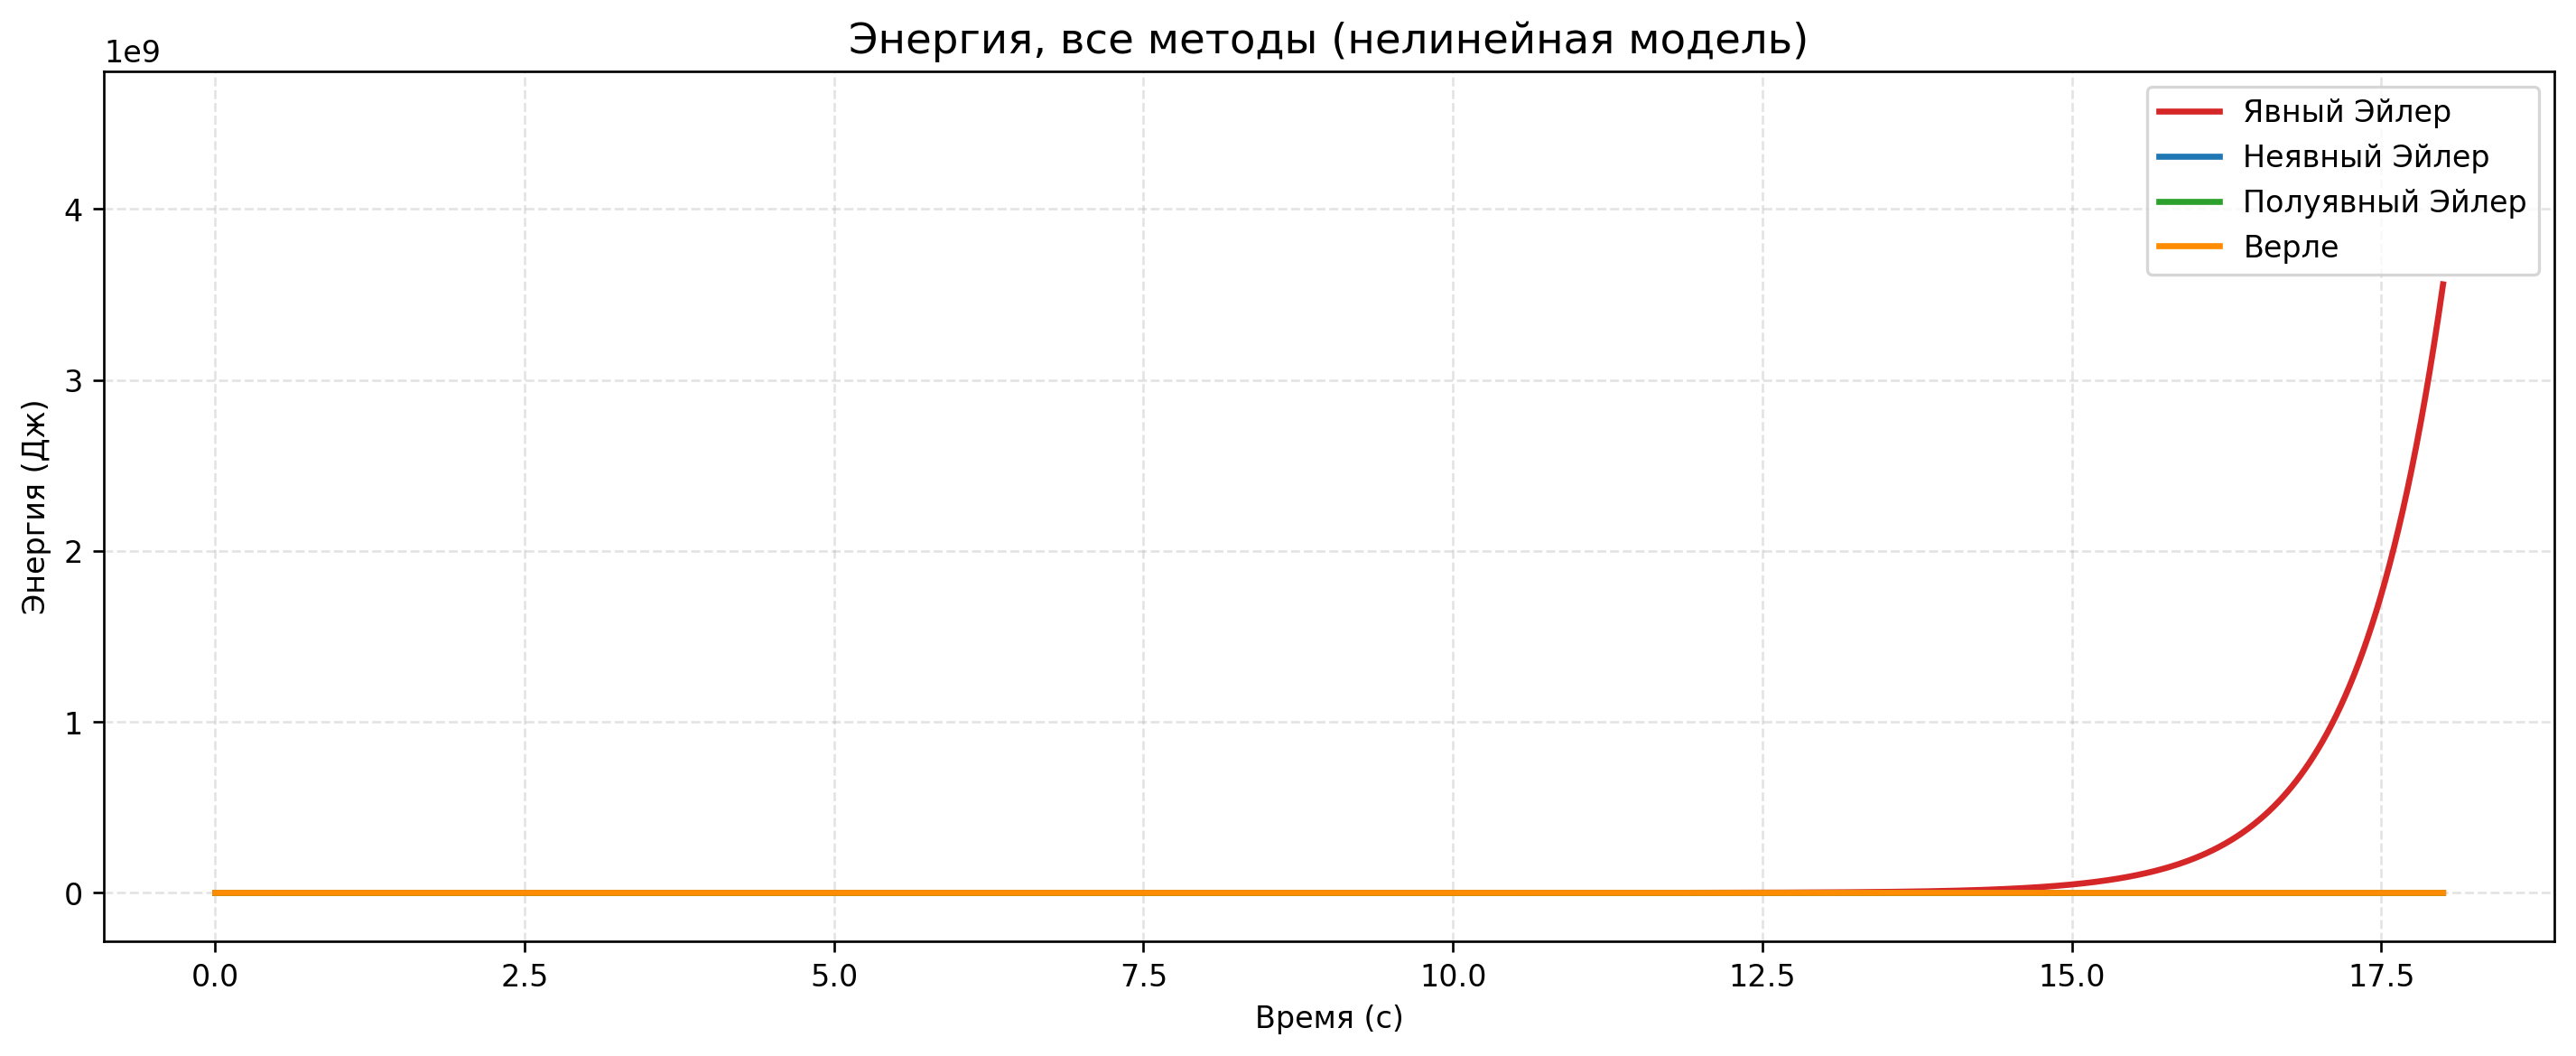

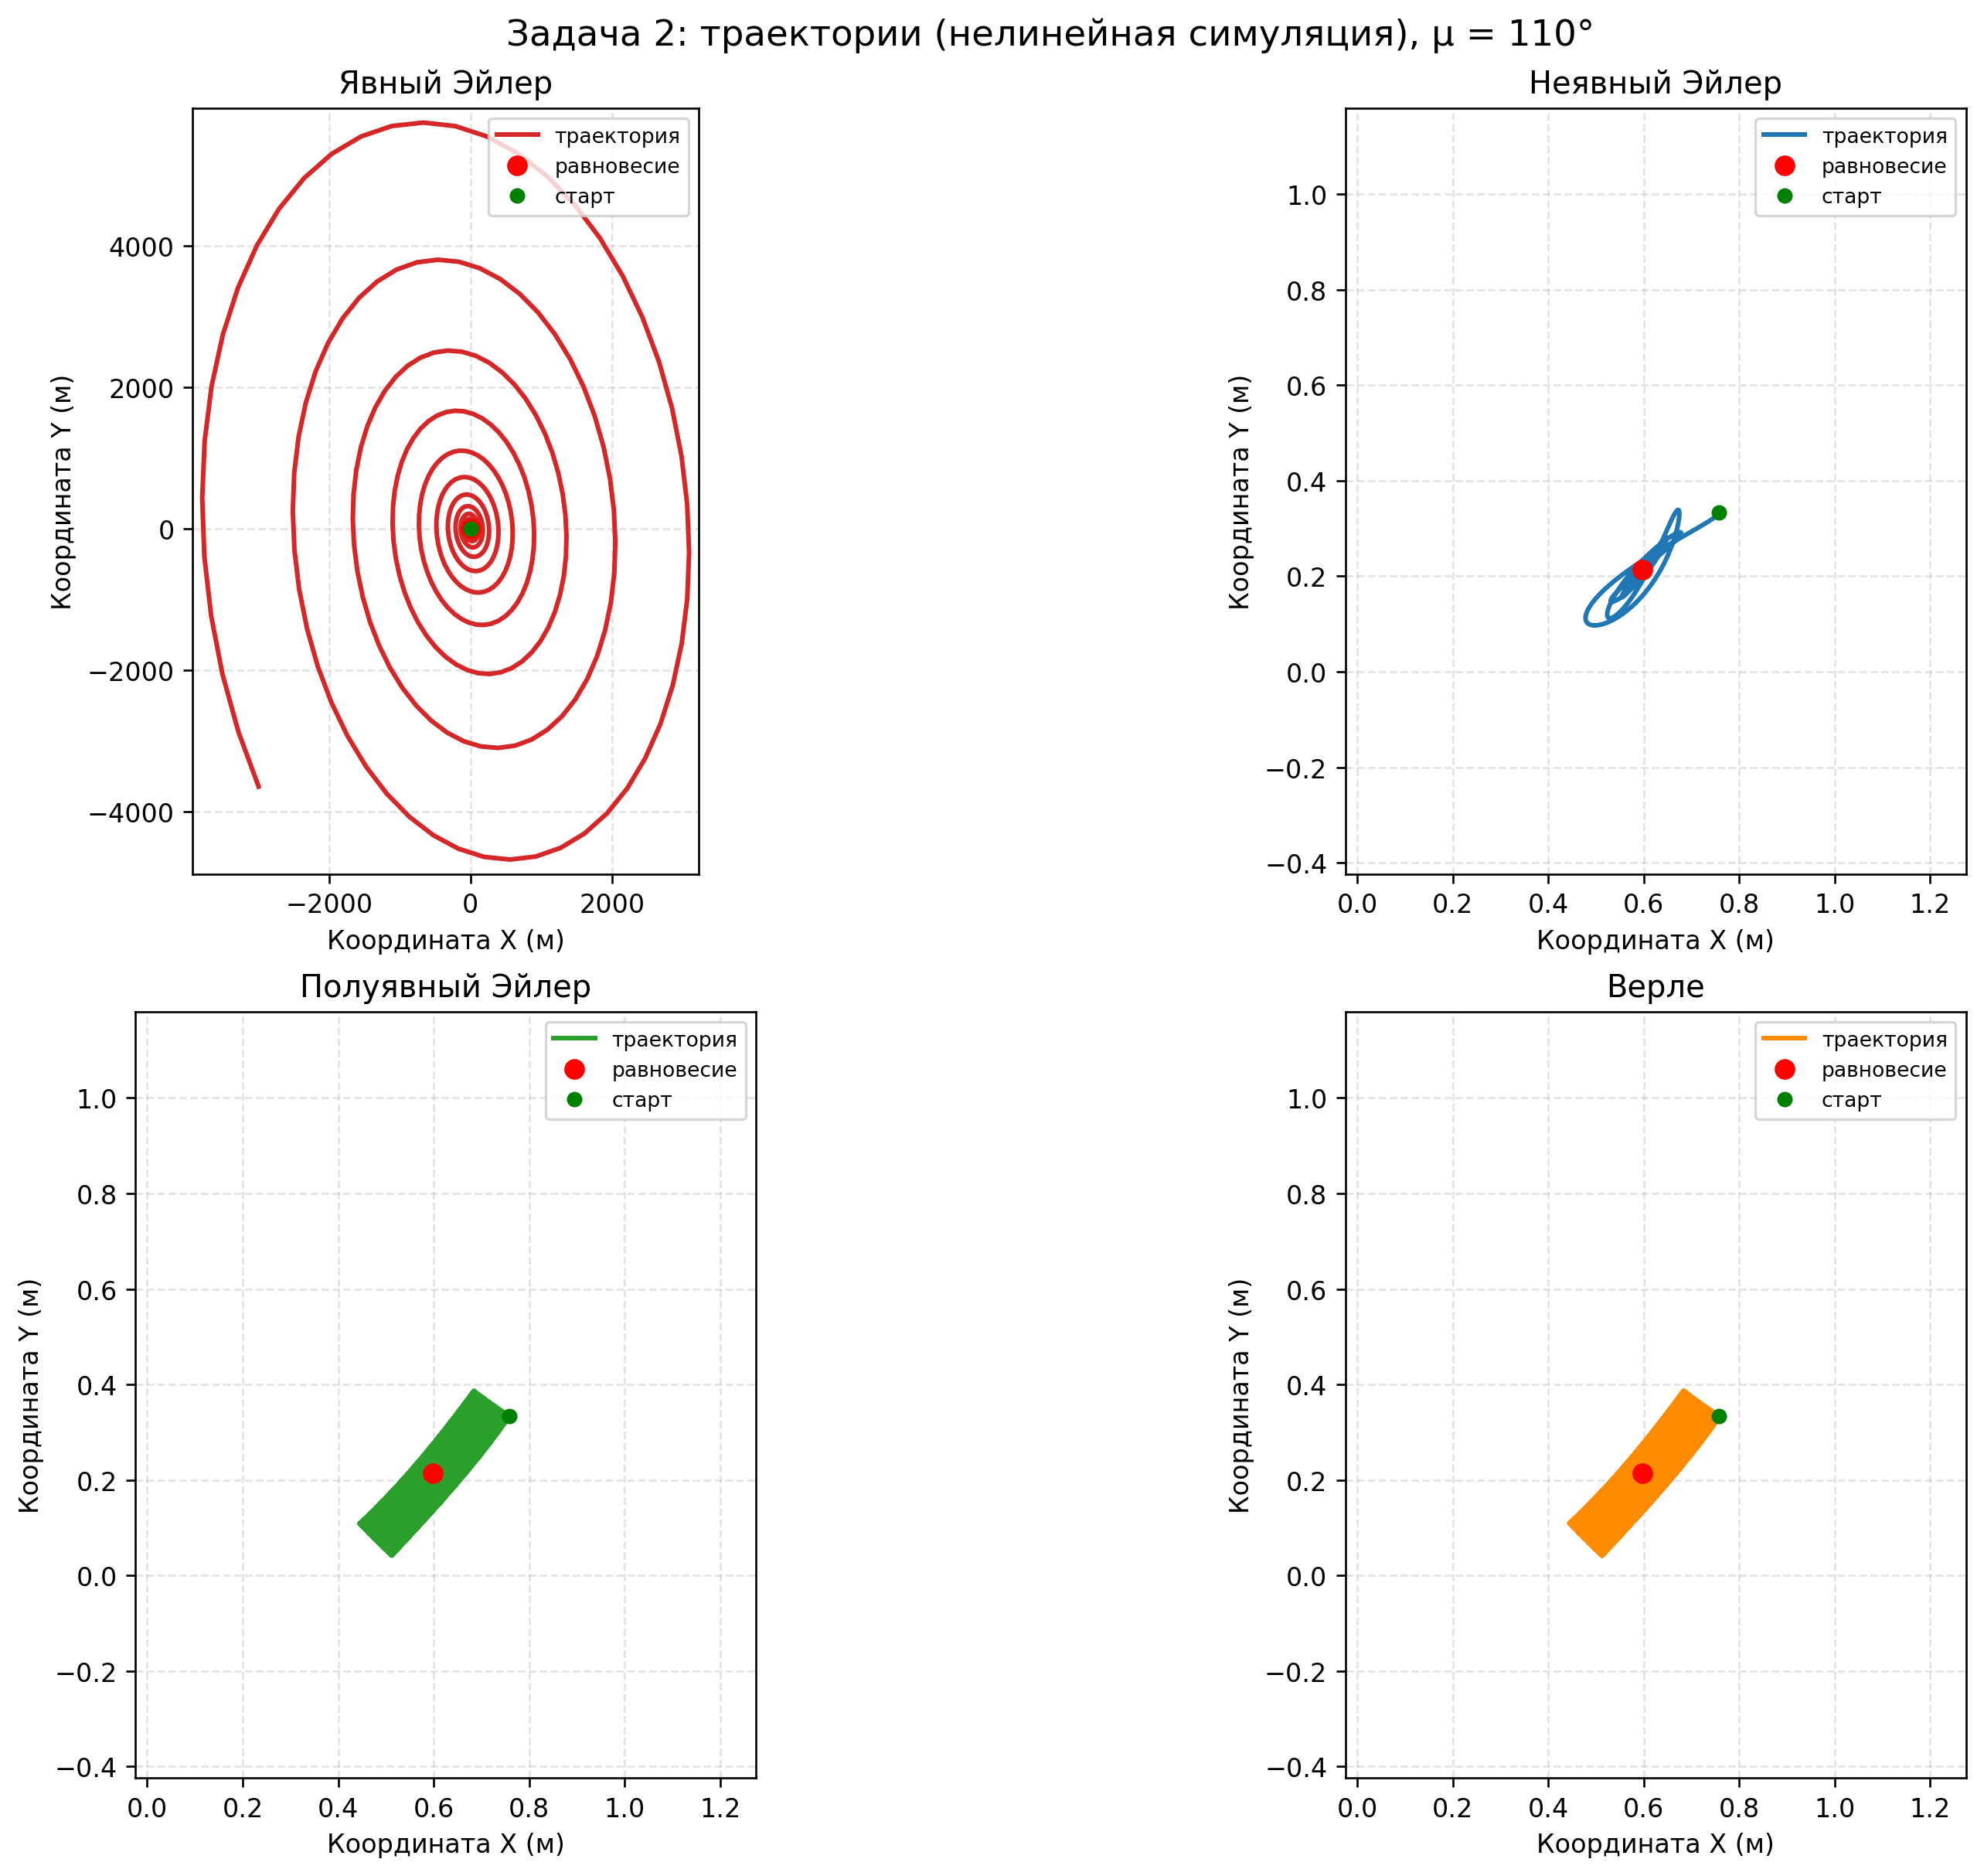

In [6]:
colors = {
    "explicit": "tab:red",
    "implicit": "tab:blue",
    "semi": "tab:green",
    "verlet": "darkorange",
}

verlet_small = results_small["verlet"]
E_vs = verlet_small["E"]

plt.figure(figsize=(12, 5))
plt.plot(ts, E_lin, color="black", lw=2, label="E_tot (линеаризация)")
plt.plot(time_small, E_vs, color="darkorange", lw=2, label="E_tot (нелинейно, Верле)")
plt.title("Энергия: линеаризация vs малая нелинейная симуляция, задача 2", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, max(float(np.max(E_lin)), float(np.max(E_vs))) * 1.5 + 1e-15)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(pos_lin[:, 0], pos_lin[:, 1], color="black", lw=2, ls="--", label="Траектория (линеаризация)")
plt.plot(verlet_small["q"][:, 0], verlet_small["q"][:, 1], color="royalblue", lw=2, label="Траектория (Верле)")
plt.plot(q_eq[0], q_eq[1], "ro", markersize=8, label="Равновесие")
plt.title("Траектория: линеаризация vs Верле (малые колебания)", fontsize=14)
plt.xlabel("X (м)")
plt.ylabel("Y (м)")
plt.axis("equal")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for mid, r in results.items():
    plt.plot(time, r["E"], color=colors[mid], lw=2, label=r["label"])
plt.title("Энергия, все методы (нелинейная модель)", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
vals = np.concatenate([r["E"] for r in results.values()])
vals = vals[np.isfinite(vals)]
span = max(float(np.max(vals)) - float(np.min(vals)), 1e-12)
plt.ylim(float(np.min(vals)) - 0.08 * span, float(np.max(vals)) + 0.35 * span)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
method_order = ("explicit", "implicit", "semi", "verlet")
for ax, method_id in zip(axes.ravel(), method_order):
    r = results[method_id]
    q = r["q"]
    ax.plot(q[:, 0], q[:, 1], color=colors[method_id], lw=1.8, label="траектория")
    ax.plot(q_eq[0], q_eq[1], "ro", markersize=7, label="равновесие")
    ax.plot(q0_methods[0], q0_methods[1], "go", markersize=5, label="старт")
    # ax.scatter(
    #     [C1[0], C2[0], C3[0]],
    #     [C1[1], C2[1], C3[1]],
    #     c=["purple", "green", "darkorange"],
    #     s=28,
    #     zorder=4,
    #     label="якоря",
    # )
    ax.set_title(r["label"], fontsize=12)
    ax.set_xlabel("Координата X (м)")
    ax.set_ylabel("Координата Y (м)")
    ax.grid(True, linestyle="--")
    ax.legend(loc="best", fontsize=8)

    xs = q[:, 0]
    ys = q[:, 1]
    ok = np.isfinite(xs) & np.isfinite(ys)
    xs = np.append(
        xs[ok],
        [float(q_eq[0]), float(q0_methods[0]), float(C1[0]), float(C2[0]), float(C3[0])],
    )
    ys = np.append(
        ys[ok],
        [float(q_eq[1]), float(q0_methods[1]), float(C1[1]), float(C2[1]), float(C3[1])],
    )
    xmin, xmax = float(np.min(xs)), float(np.max(xs))
    ymin, ymax = float(np.min(ys)), float(np.max(ys))
    sx = max(xmax - xmin, 1e-9)
    sy = max(ymax - ymin, 1e-9)
    px = max(0.02 * sx, 1e-6)
    py = max(0.02 * sy, 1e-6)
    ax.set_xlim(xmin - px, xmax + px)
    ax.set_ylim(ymin - py, ymax + py)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Задача 2: траектории (нелинейная симуляция), μ = 110°", fontsize=14)
plt.show()


## Выводы по графикам (задача 2)

- **Линеаризация:** энергия почти постоянна; траектория — гладкая кривая вокруг $q_0$ при малых амплитудах (две нормальные моды).
- **Совпадение с малой нелинейной Верле:** если кривые близки, линеаризация адекватна; расхождение — сигнал о больших нелинейностях.
- **Четыре метода на нелинейной системе:** типично явный Эйлер разгоняет энергию, неявный — искусственно гасит, полуявный и Верле ближе к «консервативному» поведению при том же $\Delta t$.
- **Нелинейные траектории по методам:** сетка $2\times 2$ — по одному подграфику на интегратор, свой зум (учитываются равновесие, старт и якоря $C_1,C_2,C_3$ в пределах осей).
